In [1]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import omicverse as ov
import scvi
from scvi.model.utils import mde

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.5.3, Tutorials: https://omicverse.readthedocs.io/


[rank: 0] Global seed set to 0


In [2]:
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (3, 3)

In [3]:
# Change the working directory to the Garfield folder (if needed)
os.chdir('/storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration')
os.getcwd()

'/storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration'

In [4]:
import scanpy as sc

# Step 1: Define the paths to your 5 h5ad files
file_paths = [
    "embryo_model_integration.h5ad",
    "embryo_model_integration_scarches.h5ad",
    "embryo_model_integration_scgpt.h5ad",
    "embryo_model_integration_querymap.h5ad",
    "embryo_model_integration_scPoli.h5ad"
]

# Step 2: Load each file and store the AnnData objects in a list
try:
    adata_list = [sc.read(file) for file in file_paths]
except Exception as e:
    print(f"Error loading files: {e}")
    raise

# Step 3: Standardize indices by stripping unwanted suffixes (e.g., "-1")
for i, adata in enumerate(adata_list):
    print(f"Dataset {i+1} original indices:")
    print(adata.obs_names[:10])  # Print first 10 indices for inspection
    adata.obs_names = adata.obs_names.str.replace('-1$', '', regex=True)

# Step 4: Extract the standardized indices from the first AnnData object
base_indices = adata_list[0].obs_names

# Step 5: Confirm that all indices are now the same
all_indices_match = all(
    (adata.obs_names == base_indices).all() for adata in adata_list[1:]
)

if all_indices_match:
    print("All indices match after correction.")
else:
    print("Indices still do not match. Check the following:")
    for i, adata in enumerate(adata_list):
        if not (adata.obs_names == base_indices).all():
            mismatched = adata.obs_names[adata.obs_names != base_indices]
            print(f"Dataset {i+1} mismatched indices: {mismatched}")
    raise ValueError("Indices still do not match. Please manually inspect datasets.")

# Step 6: Use the first AnnData object as the base
base_adata = adata_list[0].copy()

# Step 7: Add UMAP embeddings
umap_names = ["garfield", "scarches", "scgpt", "querymap", "scpoli"]

for i, adata in enumerate(adata_list):
    umap_key = f"X_umap_{umap_names[i]}"
    if "X_umap" not in adata.obsm:
        raise KeyError(f"X_umap not found in dataset {i+1}.")
    base_adata.obsm[umap_key] = adata.obsm["X_umap"]

# Step 8: Add custom annotations
annotation_columns = [
    "human_ref_transferred_final_lineage_unfiltered",
    "human_ref_scArches_final_lineage_pre",
    "human_ref_scgpt_final_lineage_pre",
    "human_ref_querymap_human_ref_final_lineage",
    "human_ref_final_lineage_pred"
]

for i, col in enumerate(annotation_columns):
    if col not in adata_list[i].obs:
        raise KeyError(f"Column '{col}' not found in dataset {i+1}.")
    base_adata.obs[f"{umap_names[i]}_annotation"] = adata_list[i].obs[col]

# Step 9: Add clustering information
clustering_columns = ["scANVI_res_0.5"]  # Replace with actual clustering column names if different

for i, adata in enumerate(adata_list):
    for clustering_col in clustering_columns:
        if clustering_col in adata.obs.columns:
            renamed_col = f"{umap_names[i]}_{clustering_col}"  # Rename to avoid conflicts
            base_adata.obs[renamed_col] = adata.obs[clustering_col]

# Step 10: Ensure observation names are unique in the combined AnnData object
base_adata.obs_names_make_unique()

# Step 11: Verify the structure of the combined AnnData object
print("Keys in base_adata.obsm:", list(base_adata.obsm.keys()))
print("Columns in base_adata.obs:", list(base_adata.obs.columns))


Dataset 1 original indices:
Index(['AAACCCAAGGTGCCTC-1_1_1_1', 'AAACCCACAAGTGCAG-1_1_1_1',
       'AAACCCACAGTCTCTC-1_1_1_1', 'AAACCCACAGTGTACT-1_1_1_1',
       'AAACCCAGTAACAAGT-1_1_1_1', 'AAACCCAGTTGCGAAG-1_1_1_1',
       'AAACGAAAGATGGTCG-1_1_1_1', 'AAACGCTAGATGGGCT-1_1_1_1',
       'AAACGCTGTTGCGTAT-1_1_1_1', 'AAAGAACCAATGCAGG-1_1_1_1'],
      dtype='object')
Dataset 2 original indices:
Index(['AAACCCAAGGTGCCTC-1_1_1_1', 'AAACCCACAAGTGCAG-1_1_1_1',
       'AAACCCACAGTCTCTC-1_1_1_1', 'AAACCCACAGTGTACT-1_1_1_1',
       'AAACCCAGTAACAAGT-1_1_1_1', 'AAACCCAGTTGCGAAG-1_1_1_1',
       'AAACGAAAGATGGTCG-1_1_1_1', 'AAACGCTAGATGGGCT-1_1_1_1',
       'AAACGCTGTTGCGTAT-1_1_1_1', 'AAAGAACCAATGCAGG-1_1_1_1'],
      dtype='object')
Dataset 3 original indices:
Index(['AAACCCAAGGTGCCTC-1_1_1_1', 'AAACCCACAAGTGCAG-1_1_1_1',
       'AAACCCACAGTCTCTC-1_1_1_1', 'AAACCCACAGTGTACT-1_1_1_1',
       'AAACCCAGTAACAAGT-1_1_1_1', 'AAACCCAGTTGCGAAG-1_1_1_1',
       'AAACGAAAGATGGTCG-1_1_1_1', 'AAACGCTAGATGGGC

In [5]:
# Step 12: Save the combined AnnData object
base_adata.write("combined_data_with_umaps.h5ad")

In [4]:
base_adata = sc.read_h5ad("combined_data_with_umaps.h5ad")

In [5]:
base_adata

AnnData object with n_obs × n_vars = 142232 × 35142
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_transferred_final_anno_unfiltered', 'human_ref_transferred_final_anno_uncert', 'human_ref_transferred_final_lineage_unfiltered', 'human_ref_transferred_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch', 'Unintegrated_res_0.5', 'scANVI_res_0.5', 'garfield_annotation', 'scarches_annotation', 'scgpt_annotation', 'querymap_annotation', 'scpoli_annotation', 'garfield_scANVI_res_0.5', 'scarches_scANVI_res_0.5', 'scgpt_scANVI_res_0.5', 'querymap_scANVI_res_0.5', 'scpoli_scANVI_res_0.5'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'human_ref_transferred_final_lineage_unfiltered_colors

In [7]:
# free space 
if 'adata_list' in globals():
    del adata_list

In [6]:
import scib
# Check what functions are available in your scib.metrics
print(dir(scib.metrics))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'ari', 'cell_cycle', 'clisi_graph', 'cluster_optimal_resolution', 'clustering', 'get_resolutions', 'graph_connectivity', 'highly_variable_genes', 'hvg_overlap', 'ilisi_graph', 'isolated_labels', 'isolated_labels_asw', 'isolated_labels_f1', 'kBET', 'kbet', 'lisi', 'lisi_graph', 'metrics', 'metrics_all', 'metrics_fast', 'metrics_slim', 'nmi', 'opt_louvain', 'pc_regression', 'pcr', 'pcr_comparison', 'silhouette', 'silhouette_batch', 'trajectory', 'trajectory_conservation', 'utils']


In [7]:
import traceback
import time

def calculate_bio_conservation(adata, umap_config, batch_key="orig.ident", 
                              compute_isolated_labels=True, 
                              subsample=None):
    """
    Calculate biological conservation metrics for different UMAP embeddings
    
    Parameters:
    -----------
    adata: AnnData object
    umap_config: Dictionary mapping UMAP keys to tuples of (lineage_key, cluster_key)
    batch_key: Key for batch information in adata.obs (default: "orig.ident")
    compute_isolated_labels: Whether to compute isolated label metrics (slower)
    subsample: Number of cells to subsample for faster computation (None = use all)
    
    Returns:
    --------
    DataFrame with metrics for each UMAP version
    """
    
    # Initialize results dictionary
    results = {
        'UMAP': [],
        'Lineage_key': [],
        'Cluster_key': [],
        'Silhouette': [],
        'NMI': [],
        'ARI': []
    }
    
    if compute_isolated_labels:
        results['Isolated_label_F1'] = []
        results['Isolated_label_ASW'] = []
    
    # Check if batch_key exists in adata.obs
    if batch_key not in adata.obs:
        print(f"Warning: Batch key '{batch_key}' not found in adata.obs. Some metrics may fail.")
    
    for umap_key, (label_key, cluster_key) in umap_config.items():
        start_time = time.time()
        
        # Check if UMAP key exists in adata.obsm
        if umap_key not in adata.obsm:
            print(f"Warning: UMAP key '{umap_key}' not found in adata.obsm. Skipping.")
            continue
            
        # Check if label_key exists in adata.obs
        if label_key not in adata.obs:
            print(f"Warning: Label key '{label_key}' not found in adata.obs. Skipping.")
            continue
            
        # Check if cluster_key exists in adata.obs
        if cluster_key not in adata.obs:
            print(f"Warning: Cluster key '{cluster_key}' not found in adata.obs. Skipping.")
            continue
        
        print(f"Processing {umap_key} with lineage: {label_key}, clusters: {cluster_key}")
        results['UMAP'].append(umap_key)
        results['Lineage_key'].append(label_key)
        results['Cluster_key'].append(cluster_key)
        
        # Filter out cells with missing or NA labels or clusters
        mask = ~(adata.obs[label_key].isna() | adata.obs[cluster_key].isna())
        if batch_key in adata.obs:
            mask = mask & ~(adata.obs[batch_key].isna())
        adata_filtered = adata[mask].copy()
        
        # Subsample if needed (for speed)
        if subsample is not None and subsample < adata_filtered.n_obs:
            print(f"  Subsampling from {adata_filtered.n_obs} to {subsample} cells")
            sc.pp.subsample(adata_filtered, n_obs=subsample, random_state=42)
        
        print(f"  Working with {adata_filtered.n_obs} cells")
        
        # Create a temporary AnnData with the correct UMAP key
        # The silhouette and isolated_labels functions expect 'umap' (not 'X_umap')
        temp_adata = adata_filtered.copy()
        temp_adata.obsm['umap'] = temp_adata.obsm[umap_key].copy()
                
        # Calculate Silhouette score - use embed='umap' to match the key in obsm
        try:
            sil_score = scib.metrics.silhouette(temp_adata, label_key=label_key, embed='umap')
            results['Silhouette'].append(sil_score)
            print(f"  Silhouette score: {sil_score}")
        except Exception as e:
            print(f"  Error calculating silhouette for {umap_key}: {e}")
            results['Silhouette'].append(np.nan)
        
        # Calculate NMI and ARI using the provided clustering
        try:
            nmi_score = scib.metrics.nmi(adata_filtered, cluster_key=cluster_key, label_key=label_key)
            results['NMI'].append(nmi_score)
            print(f"  NMI score: {nmi_score}")
        except Exception as e:
            print(f"  Error calculating NMI for {umap_key}: {e}")
            results['NMI'].append(np.nan)
            
        try:
            ari_score = scib.metrics.ari(adata_filtered, cluster_key=cluster_key, label_key=label_key)
            results['ARI'].append(ari_score)
            print(f"  ARI score: {ari_score}")
        except Exception as e:
            print(f"  Error calculating ARI for {umap_key}: {e}")
            results['ARI'].append(np.nan)
        
        # Calculate isolated label metrics (only if requested)
        if compute_isolated_labels:
            print(f"  Computing isolated label metrics (may take a while)...")
            try:
                # Match the embedding name with what's in obsm ('umap')
                iso_f1 = scib.metrics.isolated_labels_f1(
                    temp_adata, 
                    label_key=label_key,
                    batch_key=batch_key,
                    embed='umap',  # Must match key in obsm
                    iso_threshold=20,
                    verbose=False
                )
                results['Isolated_label_F1'].append(iso_f1)
                print(f"  Isolated label F1 score: {iso_f1}")
            except Exception as e:
                print(f"  Error calculating isolated labels F1 for {umap_key}: {e}")
                results['Isolated_label_F1'].append(np.nan)
                
            try:
                # Match the embedding name with what's in obsm ('umap')
                iso_asw = scib.metrics.isolated_labels_asw(
                    temp_adata, 
                    label_key=label_key,
                    batch_key=batch_key,
                    embed='umap',  # Must match key in obsm
                    iso_threshold=20,
                    verbose=False
                )
                results['Isolated_label_ASW'].append(iso_asw)
                print(f"  Isolated label ASW score: {iso_asw}")
            except Exception as e:
                print(f"  Error calculating isolated labels ASW for {umap_key}: {e}")
                results['Isolated_label_ASW'].append(np.nan)
        
        elapsed_time = time.time() - start_time
        print(f"  Completed in {elapsed_time:.2f} seconds")
    
    return pd.DataFrame(results)

# Define the mapping between UMAP versions and their corresponding lineage labels and clustering
umap_config = {
    "X_umap_garfield": ("garfield_annotation", "garfield_scANVI_res_0.5"),
    "X_umap_scarches": ("scarches_annotation", "scarches_scANVI_res_0.5"),
    "X_umap_scgpt": ("scgpt_annotation", "scgpt_scANVI_res_0.5"),
    "X_umap_querymap": ("querymap_annotation", "querymap_scANVI_res_0.5"),
    "X_umap_scpoli": ("scpoli_annotation", "scpoli_scANVI_res_0.5")
}

# Calculate metrics - using a subsample and skipping isolated labels for speed
print("First calculating basic metrics only...")
metrics_df_basic = calculate_bio_conservation(
    base_adata, 
    umap_config, 
    batch_key="orig.ident", 
    compute_isolated_labels=False,  # Skip slow isolated label metrics
    subsample=None  # Use all cells for basic metrics (they're fast)
)

print("\nBasic Results:")
print(metrics_df_basic)



First calculating basic metrics only...
Processing X_umap_garfield with lineage: garfield_annotation, clusters: garfield_scANVI_res_0.5
  Working with 142232 cells
  Silhouette score: 0.3877919167280197
  NMI score: 0.36327794916926154
  ARI score: 0.18558389084387214
  Completed in 441.42 seconds
Processing X_umap_scarches with lineage: scarches_annotation, clusters: scarches_scANVI_res_0.5
  Working with 142232 cells
  Silhouette score: 0.5064387302845716
  NMI score: 0.6024346567519482
  ARI score: 0.5022833179494303
  Completed in 205.95 seconds
Processing X_umap_scgpt with lineage: scgpt_annotation, clusters: scgpt_scANVI_res_0.5
  Working with 142232 cells
  Silhouette score: 0.4553561098873615
  NMI score: 0.39547444404938864
  ARI score: 0.22656995538747926
  Completed in 221.05 seconds
Processing X_umap_querymap with lineage: querymap_annotation, clusters: querymap_scANVI_res_0.5
  Working with 142232 cells
  Silhouette score: 0.47338263876736164
  NMI score: 0.569016371857075

In [9]:
# Save results
metrics_df_basic.to_csv('/storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration/scib_benchmarking.csv', index=True)


Method Rankings:
  Method  Silhouette_rank  NMI_rank  ARI_rank  avg_rank
  Scpoli              1.0       1.0       1.0       1.0
Scarches              2.0       2.0       2.0       2.0
Querymap              3.0       3.0       3.0       3.0
   Scgpt              4.0       4.0       4.0       4.0
Garfield              5.0       5.0       5.0       5.0

Best method for each metric:
Silhouette: Scpoli (0.561)
NMI: Scpoli (0.648)
ARI: Scpoli (0.577)

Overall best method (by average normalized score):
Scpoli (normalized score: 1.000)

Analysis complete! Results saved to 'annotation_comparison' directory.


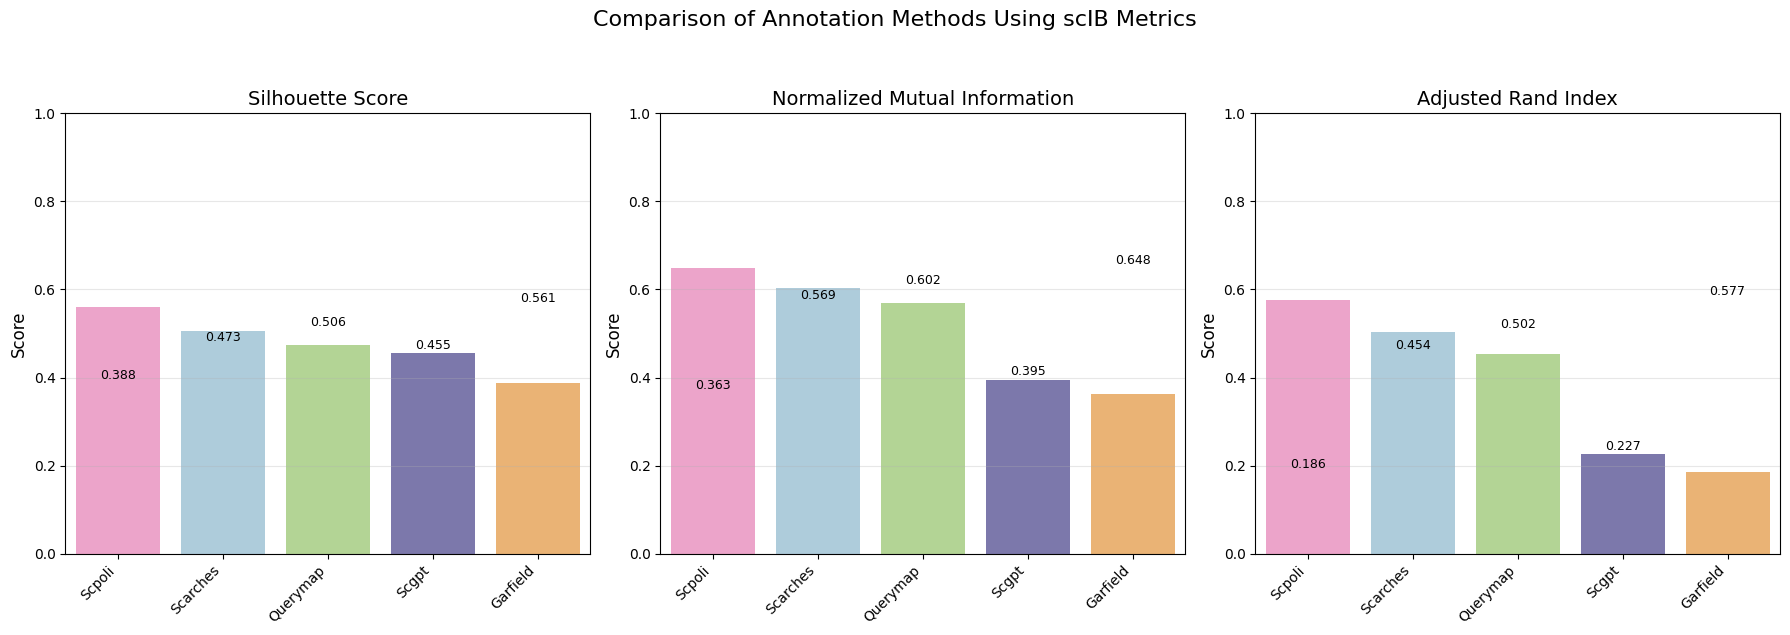

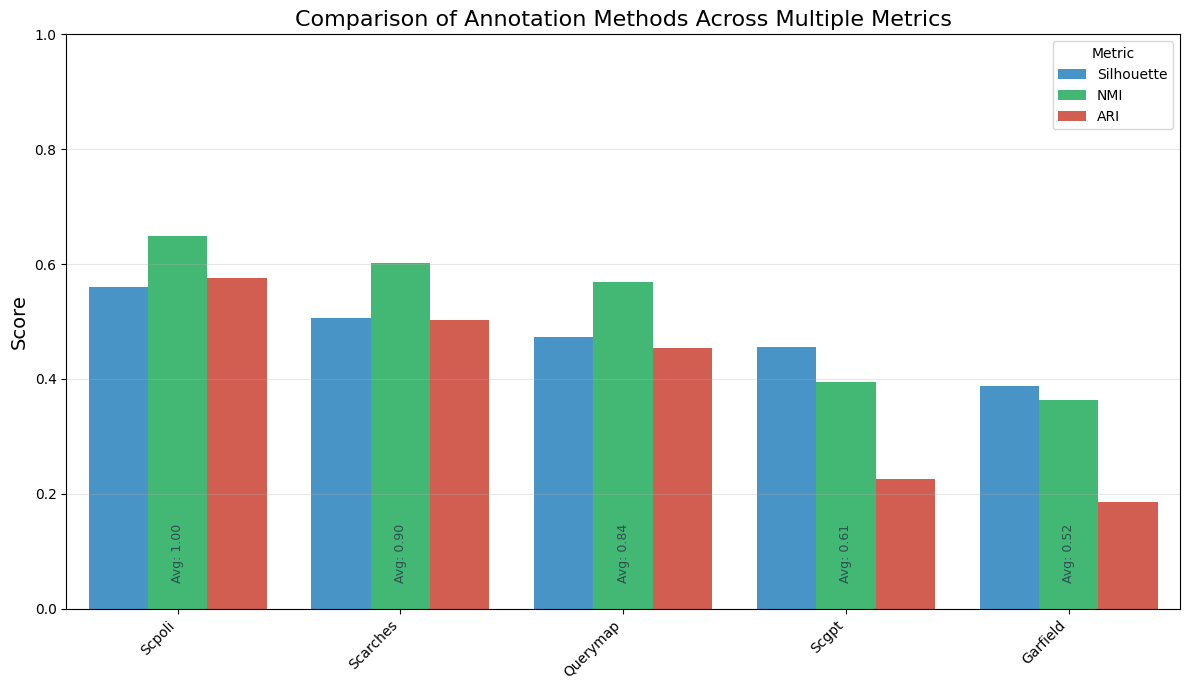

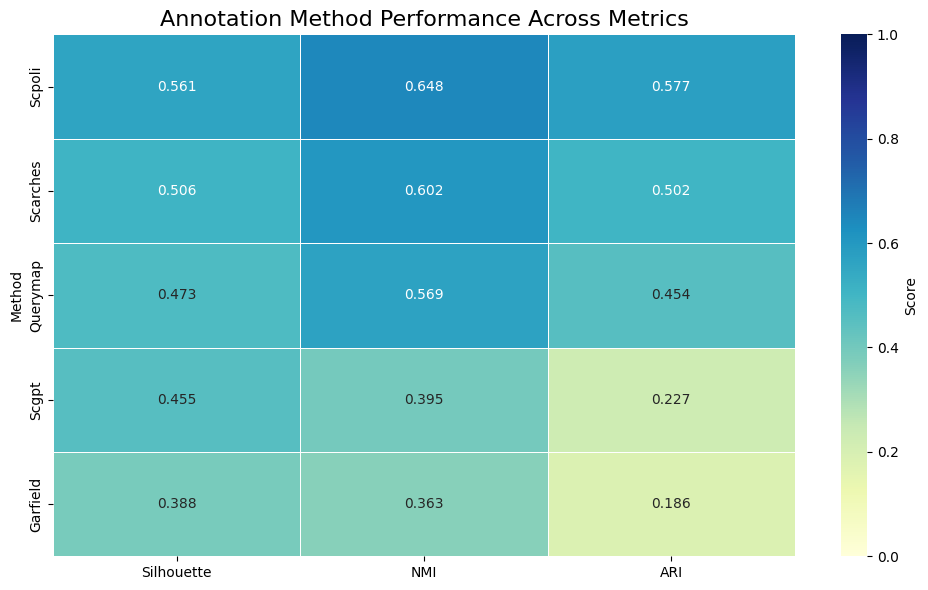

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output directory if it doesn't exist
os.makedirs("annotation_comparison", exist_ok=True)

# Load the CSV file
metrics_df = pd.read_csv('/storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration/scib_benchmarking.csv')

# Clean up method names for better display
def clean_method_name(name):
    return name.replace('X_umap_', '').replace('_annotation', '').capitalize()

metrics_df['Method'] = metrics_df['UMAP'].apply(clean_method_name)

# Define consistent colors for each method
method_colors = {
    'Garfield': "#FDB462",   # Blue
    'Scarches': "#A6CEE3",   # Green
    'Scgpt': "#7570B3",      # Red
    'Querymap': "#B2DF8A",   # Orange
    'Scpoli': "#F898CB"      # Purple
}

# Create a figure with 3 subplots (one for each metric)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define metrics and their labels
metrics = ['Silhouette', 'NMI', 'ARI']
metric_labels = [
    'Silhouette Score',
    'Normalized Mutual Information',
    'Adjusted Rand Index'
]

# Sort methods by overall performance
# Calculate average normalized performance across metrics
metrics_df['avg_norm'] = (
    metrics_df['Silhouette'] / metrics_df['Silhouette'].max() +
    metrics_df['NMI'] / metrics_df['NMI'].max() +
    metrics_df['ARI'] / metrics_df['ARI'].max()
) / 3

# Sort by this average score
method_order = metrics_df.sort_values('avg_norm', ascending=False)['Method'].tolist()

# Create a palette matching the sorted methods
palette = [method_colors[method] for method in method_order]

# Plot each metric
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    # Create the bar plot on the appropriate subplot
    ax = axes[i]
    sns.barplot(
        x='Method', 
        y=metric, 
        data=metrics_df,
        order=method_order,
        palette=palette,
        ax=ax
    )
    
    # Add values on top of each bar
    for j, val in enumerate(metrics_df.sort_values('Method')[metrics_df.sort_values('Method')['Method'].isin(method_order)][metric]):
        ax.text(j, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)
    
    # Customize the subplot
    ax.set_title(label, fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim(0, 1)  # All metrics are in range [0,1]
    ax.grid(axis='y', alpha=0.3)
    
    # Rotate x-axis labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Add an overall title
fig.suptitle('Comparison of Annotation Methods Using scIB Metrics', fontsize=16, y=1.05)

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('annotation_comparison/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('annotation_comparison/metrics_comparison.pdf', bbox_inches='tight')

# Also create a single combined metric plot
plt.figure(figsize=(12, 7))

# Melt the dataframe for easier plotting
melted_df = pd.melt(
    metrics_df,
    id_vars=['Method', 'avg_norm'],
    value_vars=['Silhouette', 'NMI', 'ARI'],
    var_name='Metric',
    value_name='Score'
)

# Create a grouped bar plot
sns.barplot(
    x='Method', 
    y='Score', 
    hue='Metric',
    data=melted_df,
    order=method_order,
    palette=['#3498db', '#2ecc71', '#e74c3c']  # Blue, Green, Red for metrics
)

# Customize the plot
plt.title('Comparison of Annotation Methods Across Multiple Metrics', fontsize=16)
plt.xlabel('')
plt.ylabel('Score', fontsize=14)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Metric')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Add overall performance text
for i, method in enumerate(method_order):
    avg = metrics_df[metrics_df['Method'] == method]['avg_norm'].values[0]
    plt.text(i, 0.05, f'Avg: {avg:.2f}', ha='center', fontsize=9, rotation=90, color='darkslategray')

plt.tight_layout()
plt.savefig('annotation_comparison/combined_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('annotation_comparison/combined_metrics_comparison.pdf', bbox_inches='tight')

# Create a heatmap for an alternative visualization
plt.figure(figsize=(10, 6))

# Prepare data for heatmap
heatmap_data = metrics_df[['Method', 'Silhouette', 'NMI', 'ARI']].set_index('Method')
heatmap_data = heatmap_data.loc[method_order, :]  # Reorder rows based on performance

# Create the heatmap
sns.heatmap(
    heatmap_data, 
    annot=True, 
    cmap='YlGnBu', 
    linewidths=.5, 
    fmt='.3f', 
    vmin=0, 
    vmax=1,
    cbar_kws={'label': 'Score'}
)

# Customize the heatmap
plt.title('Annotation Method Performance Across Metrics', fontsize=16)
plt.tight_layout()
plt.savefig('annotation_comparison/metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.savefig('annotation_comparison/metrics_heatmap.pdf', bbox_inches='tight')

# Calculate and display ranking for each metric
rank_df = metrics_df[['Method', 'Silhouette', 'NMI', 'ARI']].copy()
for metric in metrics:
    rank_df[f'{metric}_rank'] = rank_df[metric].rank(ascending=False)

# Calculate average rank
rank_df['avg_rank'] = rank_df[[f'{metric}_rank' for metric in metrics]].mean(axis=1)

# Sort by average rank
rank_df = rank_df.sort_values('avg_rank')

# Save rankings to CSV
rank_df.to_csv('annotation_comparison/method_rankings.csv', index=False)

# Print summary of rankings
print("\nMethod Rankings:")
print(rank_df[['Method'] + [f'{metric}_rank' for metric in metrics] + ['avg_rank']].to_string(index=False))

print("\nBest method for each metric:")
for metric in metrics:
    best_method = metrics_df.loc[metrics_df[metric].idxmax()]['Method']
    best_score = metrics_df.loc[metrics_df[metric].idxmax()][metric]
    print(f"{metric}: {best_method} ({best_score:.3f})")

print("\nOverall best method (by average normalized score):")
best_overall = metrics_df.loc[metrics_df['avg_norm'].idxmax()]
print(f"{best_overall['Method']} (normalized score: {best_overall['avg_norm']:.3f})")

print("\nAnalysis complete! Results saved to 'annotation_comparison' directory.")